In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, average_precision_score, roc_curve, roc_auc_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.calibration import calibration_curve
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsClassifier

In [2]:
#zmienna globalna
WIZUALIZACJE_SCIEZKA = "Wizualizacje/KNN/" #później tworzę f stringa: (f"{WIZUALIZACJE_SCIEZKA}macierz") i odwołuję się do zmiennej globalnej

In [3]:
df = pd.read_excel("df_po_oczyszczeniu.xlsx")
df_knn = df.drop(columns=['ReturningVisitor', 'OtherVisitor', 'BounceRates', 'Region1', 'Month_5', 'OperatingSystem2', 'Browser2', 'PageValues'])
df_knn

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,ExitRates,SpecialDay,Month_2,Month_3,...,Region5,Region6,Region7,Region8,Region9,NewVisitor,IfWeekend,Y_IfRevenue,OperatingSystemOther,BrowserOther
0,0,0.0,0,0.0,1,0.000000,0.200000,0.0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.100000,0.0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.200000,0.0,1,0,...,0,0,0,0,1,0,0,0,1,0
3,0,0.0,0,0.0,2,2.666667,0.140000,0.0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.050000,0.0,1,0,...,0,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.029031,0.0,0,0,...,0,0,0,0,0,0,1,0,1,1
12326,0,0.0,0,0.0,5,465.750000,0.021333,0.0,0,0,...,0,0,0,0,0,0,1,0,0,0
12327,0,0.0,0,0.0,6,184.250000,0.086667,0.0,0,0,...,0,0,0,0,0,0,1,0,0,0
12328,4,75.0,0,0.0,15,346.000000,0.021053,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df_knn.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'ExitRates', 'SpecialDay', 'Month_2', 'Month_3', 'Month_6', 'Month_7',
       'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12',
       'OperatingSystem1', 'OperatingSystem3', 'Browser1', 'Region2',
       'Region3', 'Region4', 'Region5', 'Region6', 'Region7', 'Region8',
       'Region9', 'NewVisitor', 'IfWeekend', 'Y_IfRevenue',
       'OperatingSystemOther', 'BrowserOther'],
      dtype='object')

In [5]:
X = df_knn.drop('Y_IfRevenue', axis=1)
Y = df_knn['Y_IfRevenue']

#podział na zbiór testowy i walidacyjny
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42, stratify=Y)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.30, random_state=42, stratify=Y_train_val)


In [6]:
#Obcięcie wartości odstających

kol_do_winsoryzacji = []
for col in df_knn.columns:
    if col != 'SpecialDay' and len(df_knn[col].unique()) > 2:
        kol_do_winsoryzacji.append(col)
        print("dodano kolumnę", col)

winsor_limits = {}
for col in kol_do_winsoryzacji:
    Q = X_train[col].quantile(0.9)
    winsor_limits[col] = Q
    X_train[col] = X_train[col].clip(0, Q) # obcinam wartości odstające na podstawie kwantyla 0,9 obliczonego na x-train
    X_val[col]   = X_val[col].clip(0, Q)
    X_test[col]  = X_test[col].clip(0, Q)


dodano kolumnę Administrative
dodano kolumnę Administrative_Duration
dodano kolumnę Informational
dodano kolumnę Informational_Duration
dodano kolumnę ProductRelated
dodano kolumnę ProductRelated_Duration
dodano kolumnę ExitRates


In [7]:
#skalowanie zmiennych - tylko zmienne niebinarne
kolumny_do_skalowania = []
kolumny_binarne = []

for column in X.columns:
    if len(X[column].unique()) > 2:
        kolumny_do_skalowania.append(column)
    else:
        kolumny_binarne.append(column)

X_train_binarne = X_train[kolumny_binarne]
X_val_binarne = X_val[kolumny_binarne]
X_test_binarne = X_test[kolumny_binarne]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[kolumny_do_skalowania])
X_val_scaled = scaler.transform(X_val[kolumny_do_skalowania])
X_test_scaled = scaler.transform(X_test[kolumny_do_skalowania])

# zamiana array -> DataFrame
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=kolumny_do_skalowania,
    index=X_train.index)
X_val_scaled_df = pd.DataFrame(
    X_val_scaled,
    columns=kolumny_do_skalowania,
    index=X_val.index)
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=kolumny_do_skalowania,
    index=X_test.index)

#Sklejenie binarnych i skalowanych zmiennych
X_train_final = pd.concat([X_train_scaled_df, X_train_binarne], axis=1)
X_val_final = pd.concat([X_val_scaled_df, X_val_binarne], axis=1)
X_test_final = pd.concat([X_test_scaled_df, X_test_binarne], axis=1)
#uporządkowanie kolumn
X_train_final = X_train_final[X.columns]
X_val_final = X_val_final[X.columns]
X_test_final = X_test_final[X.columns]

# Pierwsza ocena

In [8]:
#trenuję model
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean')
knn.fit(X_train_final, Y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [9]:
#pierwsza ocena
Y_val_pred = knn.predict(X_val_final)

val_accuracy = accuracy_score(Y_val, Y_val_pred)
val_recall = recall_score(Y_val, Y_val_pred)
print("Accuracy (val):", val_accuracy)
print("Recall (val):", val_recall)

Accuracy (val): 0.8247104247104247
Recall (val): 0.14962593516209477


# Dobór najlepszego K, metryka euklidesowa

In [10]:
#dobór najlepszego K - pętla po K
k_values = range(1, 31) #3ci argument to step co ile sie zmienia
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean'
    )

    knn.fit(X_train_final, Y_train)
    Y_val_pred = knn.predict(X_val_final)

    acc = accuracy_score(Y_val, Y_val_pred)
    val_accuracies.append(acc)

#najlepsze k
best_k = k_values[np.argmax(val_accuracies)]
best_val_acc = max(val_accuracies)

print("Najlepsze k:", best_k)
print("Accuracy:", best_val_acc)

Najlepsze k: 25
Accuracy: 0.844015444015444


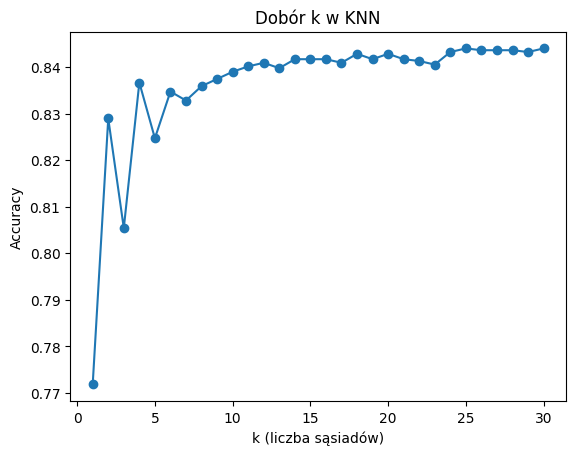

In [11]:
plt.figure()
plt.plot(k_values, val_accuracies, marker='o')
plt.xlabel("k (liczba sąsiadów)")
plt.ylabel("Accuracy")
plt.title("Dobór k w KNN")
plt.show()

In [29]:
k_values = range(1,50, 2)
val_recalls = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors= k,
        metric='euclidean'
    )

    knn.fit(X_train_final, Y_train)
    Y_val_pred = knn.predict(X_val_final)

    recall = recall_score(Y_val, Y_val_pred)
    val_recalls.append(recall)

#najlepsze k
best_k = k_values[np.argmax(val_recalls)]
best_val_recall = max(val_recalls)

print("Najlepsze k:", best_k)
print("Recall:", best_val_recall)

Najlepsze k: 1
Recall: 0.2817955112219451


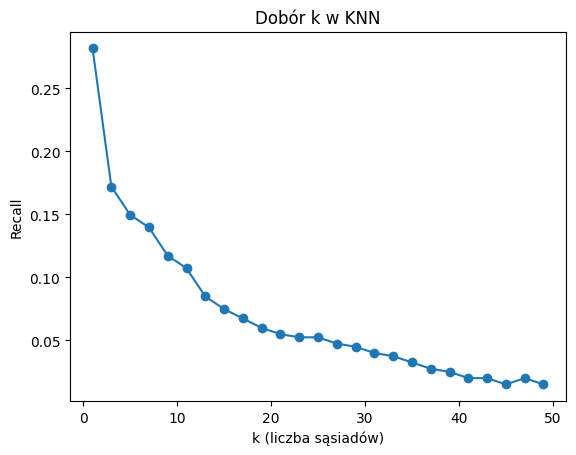

In [30]:
plt.figure()
plt.plot(k_values, val_recalls, marker='o')
plt.xlabel("k (liczba sąsiadów)")
plt.ylabel("Recall")
plt.title("Dobór k w KNN")
plt.show()

# Zmiana weights na 'distance'

Najlepsze k: 1
Recall: 0.2817955112219451


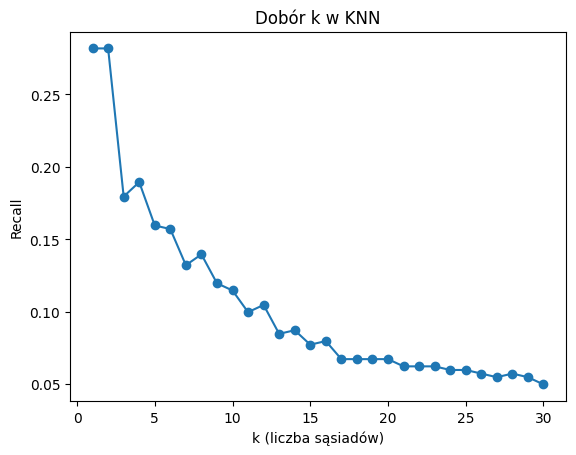

In [14]:
k_values = range(1,31)
val_recalls = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors= k,
        metric='euclidean',
        weights='distance'
    )

    knn.fit(X_train_final, Y_train)
    Y_val_pred = knn.predict(X_val_final)

    recall = recall_score(Y_val, Y_val_pred)
    val_recalls.append(recall)

#najlepsze k
best_k = k_values[np.argmax(val_recalls)]
best_val_recall = max(val_recalls)

print("Najlepsze k:", best_k)
print("Recall:", best_val_recall)

plt.figure()
plt.plot(k_values, val_recalls, marker='o')
plt.xlabel("k (liczba sąsiadów)")
plt.ylabel("Recall")
plt.title("Dobór k w KNN")
plt.show()

# Zmiana metryki

Najlepsze k: 1
Recall: 0.27680798004987534


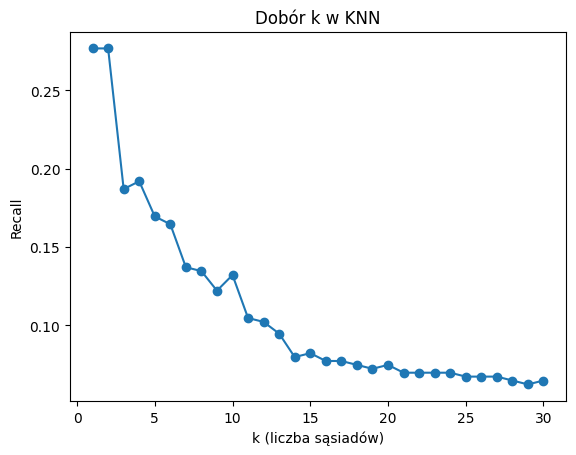

In [15]:
#MANHATTAN
k_values = range(1,31)
val_recalls = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors= k,
        metric='manhattan',
        weights='distance'
    )

    knn.fit(X_train_final, Y_train)
    Y_val_pred = knn.predict(X_val_final)

    recall = recall_score(Y_val, Y_val_pred)
    val_recalls.append(recall)

#najlepsze k
best_k = k_values[np.argmax(val_recalls)]
best_val_recall = max(val_recalls)

print("Najlepsze k:", best_k)
print("Recall:", best_val_recall)

plt.figure()
plt.plot(k_values, val_recalls, marker='o')
plt.xlabel("k (liczba sąsiadów)")
plt.ylabel("Recall")
plt.title("Dobór k w KNN")
plt.show()

Najlepsze k: 1
Recall: 0.2793017456359102


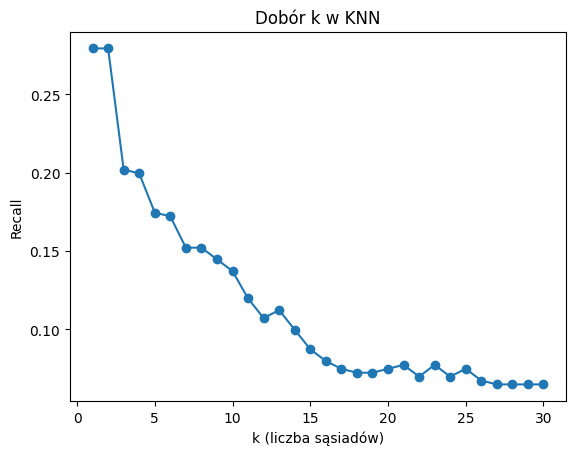

In [16]:
#COSINE
k_values = range(1,31)
val_recalls = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors= k,
        metric='cosine',
        weights='distance'
    )

    knn.fit(X_train_final, Y_train)
    Y_val_pred = knn.predict(X_val_final)

    recall = recall_score(Y_val, Y_val_pred)
    val_recalls.append(recall)

#najlepsze k
best_k = k_values[np.argmax(val_recalls)]
best_val_recall = max(val_recalls)

print("Najlepsze k:", best_k)
print("Recall:", best_val_recall)

plt.figure()
plt.plot(k_values, val_recalls, marker='o')
plt.xlabel("k (liczba sąsiadów)")
plt.ylabel("Recall")
plt.title("Dobór k w KNN")
plt.show()

# Wywalam zmienne binarne

In [34]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[kolumny_do_skalowania])
X_val_scaled = scaler.transform(X_val[kolumny_do_skalowania])
X_test_scaled = scaler.transform(X_test[kolumny_do_skalowania])


In [37]:
df_knn.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'ExitRates', 'SpecialDay', 'Month_2', 'Month_3', 'Month_6', 'Month_7',
       'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12',
       'OperatingSystem1', 'OperatingSystem3', 'Browser1', 'Region2',
       'Region3', 'Region4', 'Region5', 'Region6', 'Region7', 'Region8',
       'Region9', 'NewVisitor', 'IfWeekend', 'Y_IfRevenue',
       'OperatingSystemOther', 'BrowserOther'],
      dtype='object')

# Zmieniam próg decyzyjny

Najlepsze k: 3
Recall: 0.4613466334164589


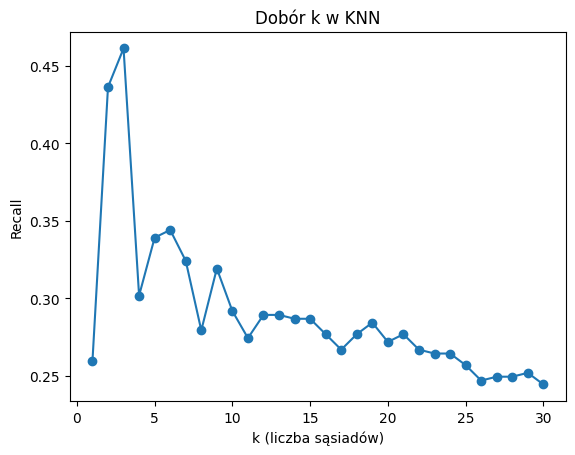

In [36]:
k_values = range(1,31)
val_recalls = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors= k,
        metric='euclidean',            #wcześniej był euclidean, nw czy cosine ma sens ale miał ładniejsze wyniki wcześniej
        weights='distance'
    )

    knn.fit(X_train_scaled, Y_train)

    # Pobranie prawdopodobieństw klasy 1
    Y_val_proba = knn.predict_proba(X_val_scaled)[:, 1]
    
    # Zastosowanie progu decyzyjnego
    Y_val_pred = (Y_val_proba >= 0.3).astype(int)

    recall = recall_score(Y_val, Y_val_pred)
    val_recalls.append(recall)

#najlepsze k
best_k = k_values[np.argmax(val_recalls)]
best_val_recall = max(val_recalls)

print("Najlepsze k:", best_k)
print("Recall:", best_val_recall)

plt.figure()
plt.plot(k_values, val_recalls, marker='o')
plt.xlabel("k (liczba sąsiadów)")
plt.ylabel("Recall")
plt.title("Dobór k w KNN")
plt.show()

Najlepsze k: 27
Accuracy: 0.7876447876447876
Najgorsze k: 3
Accuracy: 0.7042471042471042


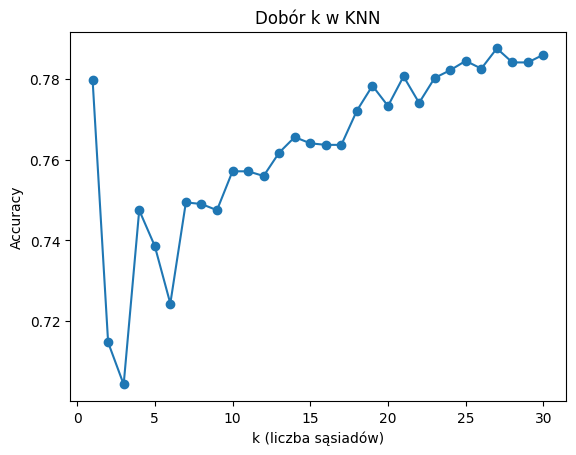

In [41]:
k_values = range(1,31)
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors= k,
        metric='euclidean',            #wcześniej był euclidean, nw czy cosine ma sens ale miał ładniejsze wyniki wcześniej
        weights='distance'
    )

    knn.fit(X_train_scaled, Y_train)

    # Pobranie prawdopodobieństw klasy 1
    Y_val_proba = knn.predict_proba(X_val_scaled)[:, 1]
    
    # Zastosowanie progu decyzyjnego
    Y_val_pred = (Y_val_proba >= 0.3).astype(int)

    acc = accuracy_score(Y_val, Y_val_pred)
    val_accuracies.append(acc)

#najlepsze k
best_k = k_values[np.argmax(val_accuracies)]
best_val_acc = max(val_accuracies)

print("Najlepsze k:", best_k)
print("Accuracy:", best_val_acc)

#najgorsze k
worst_k = k_values[np.argmin(val_accuracies)]
worst_val_acc = min(val_accuracies)

print("Najgorsze k:", worst_k)
print("Accuracy:", worst_val_acc)

plt.figure()
plt.plot(k_values, val_accuracies, marker='o')
plt.xlabel("k (liczba sąsiadów)")
plt.ylabel("Accuracy")
plt.title("Dobór k w KNN")
plt.show()

              precision    recall  f1-score   support

           0       0.88      0.75      0.81      2189
           1       0.25      0.46      0.33       401

    accuracy                           0.70      2590
   macro avg       0.57      0.61      0.57      2590
weighted avg       0.79      0.70      0.74      2590



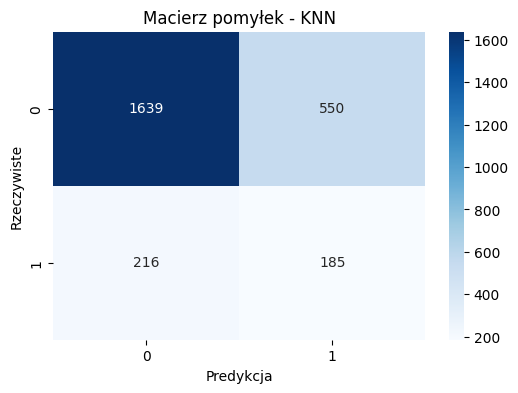

In [43]:
#raport klasyfikacji dla k = 3

knn = KNeighborsClassifier(
    n_neighbors=3,
    metric='euclidean',
    weights='distance'
)

knn.fit(X_train_scaled, Y_train)

# prawdopodobieństwa klasy 1
Y_val_proba = knn.predict_proba(X_val_scaled)[:, 1]

Y_val_pred = (Y_val_proba >= 0.3).astype(int)

cm = confusion_matrix(Y_val, Y_val_pred)
cm

print(classification_report(Y_val, Y_val_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_val, Y_val_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek - KNN")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      2189
           1       0.23      0.34      0.28       401

    accuracy                           0.72      2590
   macro avg       0.55      0.57      0.55      2590
weighted avg       0.77      0.72      0.74      2590



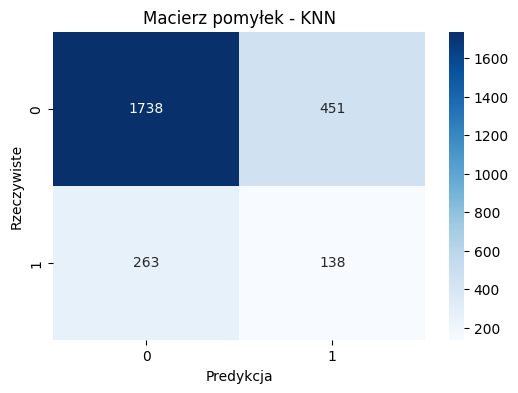

In [ ]:
#raport klasyfikacji dla k = 6

knn = KNeighborsClassifier(
    n_neighbors=6,
    metric='euclidean',
    weights='distance'
)

knn.fit(X_train_scaled, Y_train)

# prawdopodobieństwa klasy 1
Y_val_proba = knn.predict_proba(X_val_scaled)[:, 1]

Y_val_pred = (Y_val_proba >= 0.3).astype(int)

cm = confusion_matrix(Y_val, Y_val_pred)
cm

print(classification_report(Y_val, Y_val_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_val, Y_val_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek - KNN")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

# Ocena na podst danych testowych

              precision    recall  f1-score   support

           0       0.88      0.75      0.81      3127
           1       0.23      0.42      0.30       572

    accuracy                           0.70      3699
   macro avg       0.56      0.59      0.55      3699
weighted avg       0.78      0.70      0.73      3699



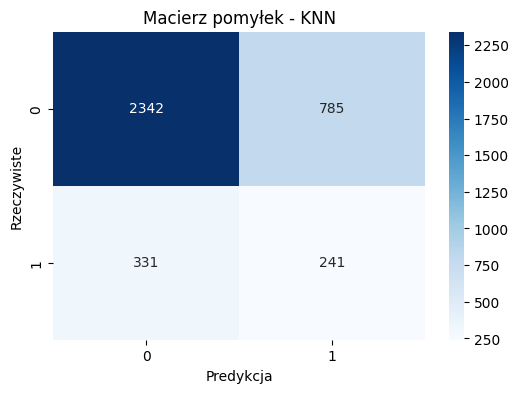

In [44]:
#ocena na podstawie danych testowych
knn = KNeighborsClassifier(
    n_neighbors=3,
    metric='euclidean',
    weights='distance'
)

knn.fit(X_train_scaled, Y_train)

# prawdopodobieństwa klasy 1
Y_test_proba = knn.predict_proba(X_test_scaled)[:, 1]

Y_test_pred = (Y_test_proba >= 0.3).astype(int)

cm = confusion_matrix(Y_test, Y_test_pred)
cm

print(classification_report(Y_test, Y_test_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_test, Y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek - KNN")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

In [45]:
from sklearn.inspection import permutation_importance

In [46]:
X_test_scaled_df = pd.DataFrame(  #przekształcam x_test_scaled na df
    X_test_scaled,
    columns=kolumny_do_skalowania
)

In [47]:
result = permutation_importance(
    knn,
    X_test_scaled,
    Y_test,
    n_repeats=10,
    scoring='recall',
    random_state=42
)

importances = pd.Series(
    result.importances_mean,
    index=X_test_scaled_df.columns
).sort_values(ascending=False)

In [50]:
print(importances.round(4))

ExitRates                  0.0392
ProductRelated_Duration    0.0241
SpecialDay                 0.0056
ProductRelated             0.0054
Informational              0.0052
Administrative             0.0037
Informational_Duration    -0.0010
Administrative_Duration   -0.0042
dtype: float64


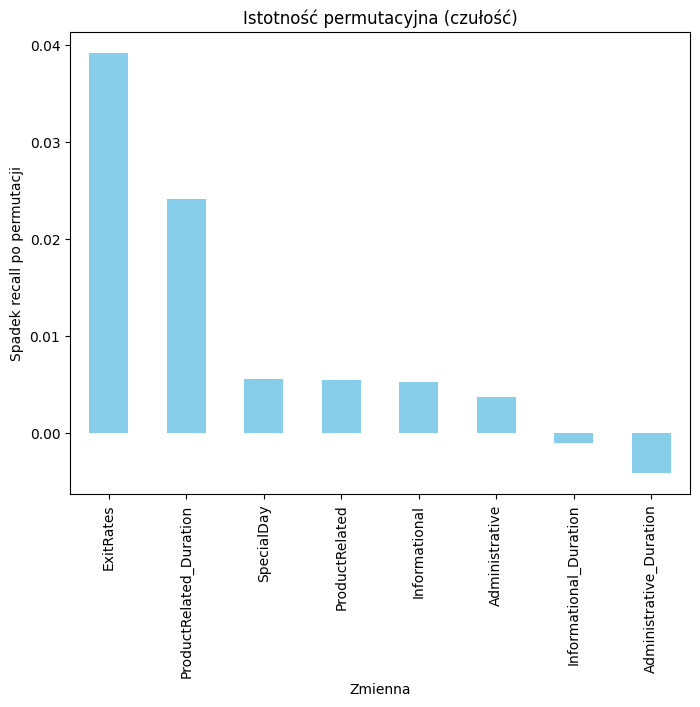

In [49]:
plt.figure(figsize=(8,6))
importances.plot(kind='bar', color='skyblue')
plt.title('Istotność permutacyjna (czułość)')
plt.ylabel('Spadek recall po permutacji')
plt.xlabel('Zmienna')
plt.show()